In [9]:
#STEPS TO FOLLOW
#LOAD AND LABEL THE DATASET
# PREPROCESS THE DATA AND CREATE DATA GENERATORS
# LOAD A PRETRAINED MODEL
#TRAINING AND OPTIMZATION
#CONVERTING THE MODEL TO TENSOR FLOW LITE.


In [2]:
# 2 PREPROCESS THE DATA AND DATA  AUGEMENTATION
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import tensorflow as tf

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ['TF_CPP_MIN_VLOG_LEVEL'] = '3'
datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    "FOMO/dataset/train",
    target_size=(96, 96),
    batch_size=32,
    class_mode="categorical",
    subset="training"
)

val_data = datagen.flow_from_directory(
    "FOMO/dataset/val",
    target_size=(96, 96),
    batch_size=32,
    class_mode="categorical",
    subset="validation"
)


2025-03-14 10:36:26.331198: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1741941386.500499    5599 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1741941386.581633    5599 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-14 10:36:27.034747: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Found 194 images belonging to 3 classes.
Found 8 images belonging to 3 classes.


In [9]:
# 3 LOADING A PRETRAINED MODEL
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, GlobalAveragePooling2D

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(96, 96, 3), include_top=False, weights="imagenet"
)
base_model.trainable = False 

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation="relu"),
    Dense(3, activation="softmax")  
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [1]:
# 4 COMPILING AND TRAINING THE MODEL
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.002),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
model.fit(train_data, validation_data=val_data, epochs=10)



NameError: name 'model' is not defined

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.9760 - loss: 0.0852 - val_accuracy: 0.7500 - val_loss: 0.4336
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.9727 - loss: 0.1054 - val_accuracy: 0.7500 - val_loss: 0.5074
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.9773 - loss: 0.0660 - val_accuracy: 0.7500 - val_loss: 0.4445
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.9777 - loss: 0.0700 - val_accuracy: 0.8750 - val_loss: 0.3414
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.9881 - loss: 0.0752 - val_accuracy: 0.6250 - val_loss: 0.7959
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.9895 - loss: 0.0469 - val_accuracy: 0.7500 - val_loss: 0.4375
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.9890 - loss: 0.0560 - val_accuracy: 0.6250 - val_loss: 0.5935
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.9834 - loss: 0.0584 - val_accuracy: 0.8750 - val_loss: 0.3332
Epoch 9/10
7/7 

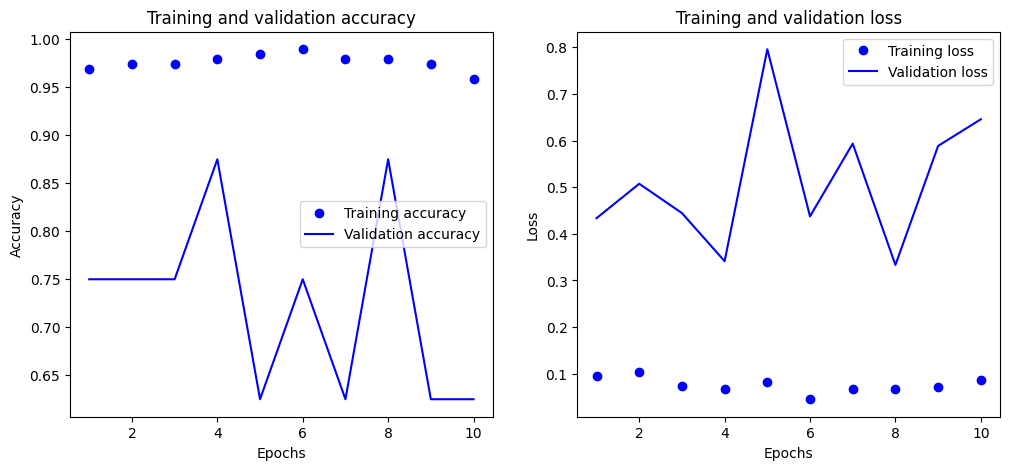

In [15]:

import matplotlib.pyplot as plt

history = model.fit(train_data, validation_data=val_data, epochs=10)

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

# Plot accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'bo', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


In [14]:
#EXPORTING THE MODEL TO TENSORFLOW LITE FORMAT
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open("fomo_model.tflite", "wb") as f:
    f.write(tflite_model)


INFO:tensorflow:Assets written to: /tmp/tmpuk851j2f/assets


INFO:tensorflow:Assets written to: /tmp/tmpuk851j2f/assets


Saved artifact at '/tmp/tmpuk851j2f'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 96, 96, 3), dtype=tf.float32, name='keras_tensor_472')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  130798882079664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130796044327696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130796044331920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130796044326992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130796044332800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130796044336672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130795999595504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130795999596560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130795999595328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130795999594272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130795999602

W0000 00:00:1741865591.029505   39777 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1741865591.029534   39777 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
2025-03-13 13:33:11.029933: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpuk851j2f
2025-03-13 13:33:11.044419: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2025-03-13 13:33:11.044457: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpuk851j2f
I0000 00:00:1741865591.202605   39777 mlir_graph_optimization_pass.cc:401] MLIR V1 optimization pass is not enabled
2025-03-13 13:33:11.229644: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2025-03-13 13:33:12.304621: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpuk851j2f
2025-03-13 13:33:12.570003: I tensorflow/cc/saved_model/loader.cc:466] SavedModel 